# 16 — Inner Boundary: Edge-Vote (bounded) + search-space debug

Single focus: the **edge-vote** method on the **Model C extracted card**, with the
search ring drawn explicitly so you can see if the true border is falling **outside**
the `[MIN, MAX]` band.

**Colors**
- 🔴 **red** = outer search bound (MIN inset — nearest the card edge)
- 🟠 **orange** = inner search bound (MAX inset — deepest the search can go)
- 🔵 **blue** = selected inner boundary (the vote result)

The vote can only land **between red and orange**. If blue sits *on* red/orange — or a
profile peak is at the band edge (**RAILED**) — the true border is outside the ring,
so widen MIN/MAX for that side.

In [1]:
import os, sys, re, importlib, urllib.request
from pathlib import Path
import cv2, numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from dotenv import load_dotenv
load_dotenv("../.env.local", override=True); load_dotenv("../backend/.env", override=False)
os.environ["CARD_DETECTOR"] = "seg"
os.environ.setdefault("YOLO_WEIGHTS", "../backend/models/yolo_obb_best.pt")
sys.path.insert(0, "../backend")
import card_segmenter; importlib.reload(card_segmenter)
import grader; importlib.reload(grader)
ARTIFACTS = Path("diag"); ARTIFACTS.mkdir(exist_ok=True)
print("ROBOFLOW key:", bool(os.environ.get("ROBOFLOW_API_KEY")))

ROBOFLOW key: True


## ⚙️ Search-ring config (independent L/R and T/B; fractions of the side)

In [2]:
MIN_LR = 0.005   # left/right: nearest the edge (fraction of WIDTH)  → RED
MAX_LR = 0.100   # left/right: deepest                              → ORANGE
MIN_TB = 0.005   # top/bottom: nearest the edge (fraction of HEIGHT)
MAX_TB = 0.120   # top/bottom: deepest
CORNER_EXCL = 0.18
CANNY  = (50, 150)
BLUR   = 3       # GaussianBlur ksize before Canny (odd; 0=off)
SMOOTH = 3       # moving-average on the vote profile

In [3]:
def load_card(src):
    if os.path.exists(src): return cv2.imread(src)
    url = src
    if "ebay" in src and "i.ebayimg.com" not in src:
        m = re.search(r"[:/]g[:/]([A-Za-z0-9]+)", src)
        if m: url = f"https://i.ebayimg.com/images/g/{m.group(1)}/s-l1600.jpg"
    dst = ARTIFACTS / "loaded_card.jpg"
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=30) as r, open(dst, "wb") as f: f.write(r.read())
    return cv2.imread(str(dst))

def extract(src):
    """DEPLOYED Roboflow seg + warp → extracted 630x880 card. Returns (warped, card_boundary).
    card_boundary is the seg card EDGE — all insets are measured from it."""
    img = load_card(src) if isinstance(src, str) else src
    qr, contour, _ = grader._detect_seg(img)
    pad = grader.adaptive_padding(qr, padding_frac=grader.PADDING_FRAC)
    c = qr.mean(0); d = qr - c
    qp = qr + (d / np.linalg.norm(d, axis=1, keepdims=True).clip(min=1)) * pad
    return grader._warp_card(img, qp), grader.card_boundary_analytical(qr, qp)[1]

## Edge-vote (bounded) — returns boundary + per-side vote profiles

In [4]:
def edge_vote(warped, cb):
    """Within the [MIN,MAX] ring per side, pick the offset where the most scan-lines have
    a Canny edge. Returns content_region, insets(%), profiles, peak (px into band), band_len."""
    h, w = warped.shape[:2]
    g = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    if BLUR and BLUR >= 3: g = cv2.GaussianBlur(g, (BLUR|1, BLUR|1), 0)
    e = cv2.Canny(g, *CANNY).astype(np.float32)
    x1, y1, x2, y2 = [int(round(v*d)) for v, d in zip(cb, [w, h, w, h])]
    iw, ih = x2-x1, y2-y1
    cx, cy = int(iw*CORNER_EXCL), int(ih*CORNER_EXCL)
    lox, hix = int(iw*MIN_LR), int(iw*MAX_LR)
    loy, hiy = int(ih*MIN_TB), int(ih*MAX_TB)
    sm = lambda a: np.convolve(a, np.ones(max(1,SMOOTH))/max(1,SMOOTH), mode="same")
    prof = {"top":    sm(e[y1+loy:y1+hiy, x1+cx:x2-cx].sum(1)),
            "bottom": sm(e[y2-hiy:y2-loy, x1+cx:x2-cx][::-1].sum(1)),
            "left":   sm(e[y1+cy:y2-cy, x1+lox:x1+hix].sum(0)),
            "right":  sm(e[y1+cy:y2-cy, x2-hix:x2-lox][:, ::-1].sum(0))}
    peak = {s: int(np.argmax(p)) for s, p in prof.items()}
    cr = {"x1": (x1+lox+peak['left'])/w,  "y1": (y1+loy+peak['top'])/h,
          "x2": (x2-lox-peak['right'])/w, "y2": (y2-loy-peak['bottom'])/h}
    ins = {"L": (cr['x1']-cb[0])*100, "R": (cb[2]-cr['x2'])*100,
           "T": (cr['y1']-cb[1])*100, "B": (cb[3]-cr['y2'])*100}
    return {"content_region": cr, "insets": ins, "profiles": prof, "peak": peak}

## Debug view — red (MIN) / orange (MAX) search bounds · blue (selected) · railing check

In [5]:
def show_debug(warped, cb, res):
    h, w = warped.shape[:2]
    x1, y1, x2, y2 = cb[0]*w, cb[1]*h, cb[2]*w, cb[3]*h
    iw, ih = x2-x1, y2-y1
    rmin = (x1+iw*MIN_LR, y1+ih*MIN_TB, iw*(1-2*MIN_LR), ih*(1-2*MIN_TB))   # RED  (MIN)
    rmax = (x1+iw*MAX_LR, y1+ih*MAX_TB, iw*(1-2*MAX_LR), ih*(1-2*MAX_TB))   # ORANGE (MAX)
    cr = res['content_region']
    fig = plt.figure(figsize=(16, 9)); gs = fig.add_gridspec(2, 4)
    ax = fig.add_subplot(gs[:, 0:2]); ax.imshow(cv2.cvtColor(warped, cv2.COLOR_BGR2RGB)); ax.axis("off")
    ax.add_patch(Rectangle((x1, y1), iw, ih, fill=False, edgecolor="gray", lw=1.0, ls=":"))         # card edge (ref)
    ax.add_patch(Rectangle(rmin[:2], rmin[2], rmin[3], fill=False, edgecolor="red",    lw=1.6))      # MIN
    ax.add_patch(Rectangle(rmax[:2], rmax[2], rmax[3], fill=False, edgecolor="orange", lw=1.6))      # MAX
    ax.add_patch(Rectangle((cr['x1']*w, cr['y1']*h), (cr['x2']-cr['x1'])*w, (cr['y2']-cr['y1'])*h,
                           fill=False, edgecolor="#1e90ff", lw=2.6))                                 # selected
    ins = res['insets']
    ax.set_title("red=MIN bound · orange=MAX bound · blue=selected\n"
                 "L%.1f R%.1f T%.1f B%.1f" % (ins['L'],ins['R'],ins['T'],ins['B']), fontsize=10)
    # profiles: x=0 is RED(min) bound, x=end is ORANGE(max) bound; blue dashed = peak
    for i, s in enumerate(["top","bottom","left","right"]):
        a = fig.add_subplot(gs[i//2, 2+i%2]); p = res['profiles'][s]; pk = res['peak'][s]
        a.plot(p, color="#444")
        a.axvline(0, color="red", lw=1.5); a.axvline(len(p)-1, color="orange", lw=1.5)
        a.axvline(pk, color="#1e90ff", lw=2, ls="--")
        railed = "  ⚠RAILED" if (pk <= 1 or pk >= len(p)-2) else ""
        a.set_title(f"{s}: peak@{pk}/{len(p)-1}{railed}", fontsize=9)
        a.set_xlabel("px  RED(min) → ORANGE(max)")
    plt.tight_layout(); plt.show()

## Run — extract once, then vote + debug
Tune `MIN_*`/`MAX_*` in the config cell and re-run. **RAILED** or blue touching
red/orange ⇒ the true border is outside the ring ⇒ widen that bound.

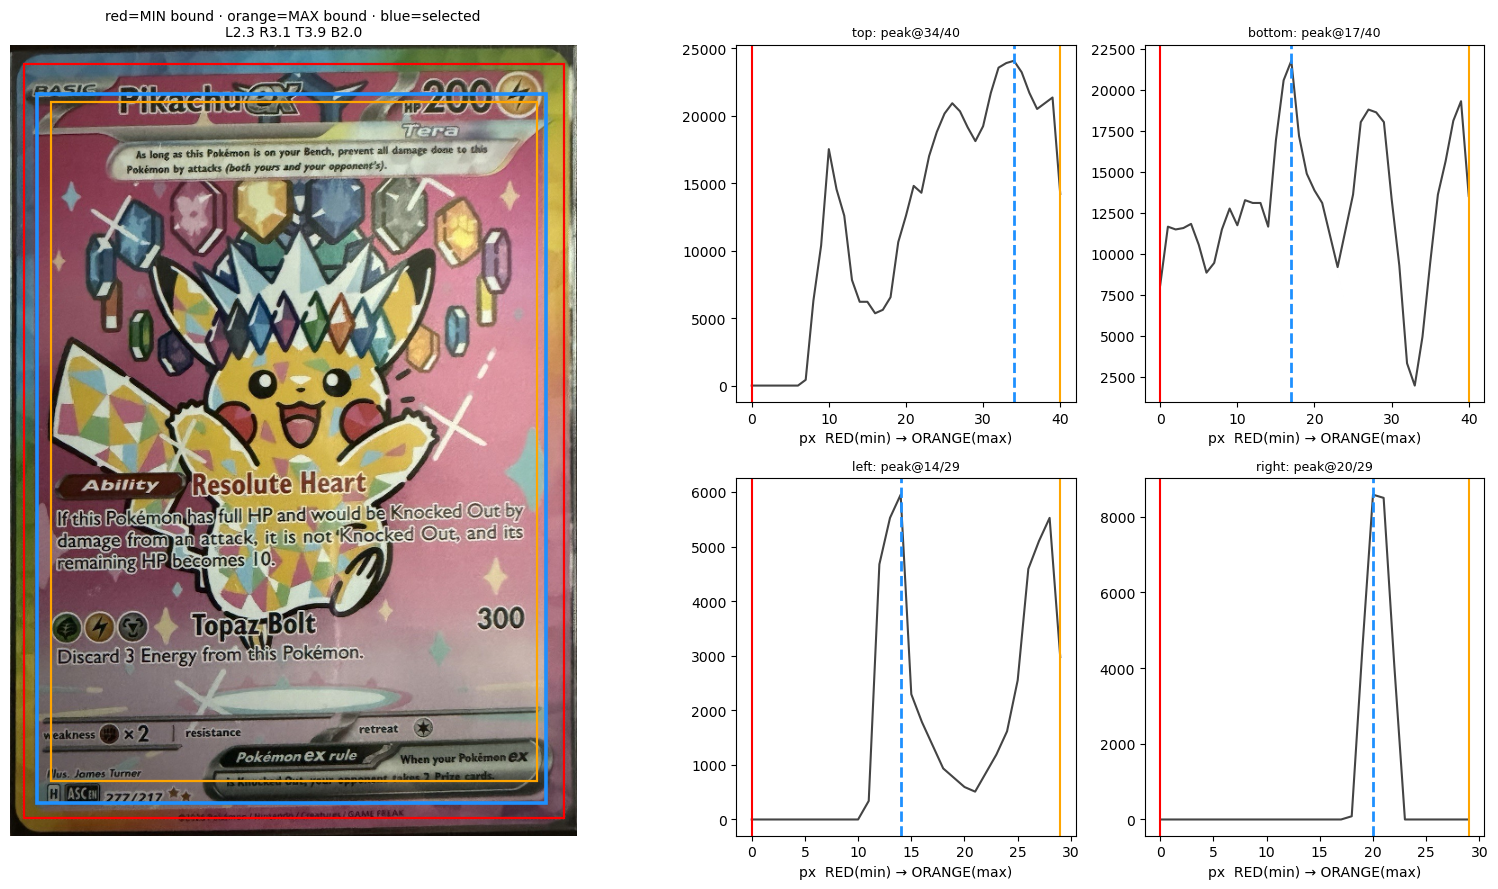

insets: {'L': 2.3, 'R': 3.1, 'T': 3.9, 'B': 2.0}


In [21]:
MIN_LR = 0.0001   # left/right: nearest the edge (fraction of WIDTH)  → RED
MAX_LR = 0.05   # left/right: deepest                              → ORANGE
MIN_TB = 0.0001   # top/bottom: nearest the edge (fraction of HEIGHT)
MAX_TB = 0.05 #%0.120 


WP, CB = extract("diag/ebay_card.jpg")   # local path or eBay URL
res = edge_vote(WP, CB)
show_debug(WP, CB, res)
print("insets:", {k: round(v,1) for k,v in res['insets'].items()})